In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import fractional_matrix_power
from psyduck import Spin
from psyduck.operations import *
from psyduck.hamiltonians import zeeman_hamiltonian, hyperfine_hamiltonian
from plotting.readout_plot import plot_transition_matrix, plot_eigenstate_decomposition

# Build Hamiltonian model

In [2]:
nucleus = Spin(I=7/2)
Ix, Iy, Iz = nucleus.get_spin_operators()

electron = Spin(I=1/2)
Sx, Sy, Sz = electron.get_spin_operators()

In [3]:
H_quad = qt.Qobj(np.load('../quadrupole modeling/H_quad_fit.npy')) # from fit
# H_quad_neutral = np.load('../quadrupole modeling/H_quad_neutral.npy') # from fit
Hz_nucleus = zeeman_hamiltonian(7/2, B0=1.4, gamma=5.55)
Hz_electron = zeeman_hamiltonian(1/2, B0=1.4, gamma=28.8e3)
H_ionized = - Hz_nucleus + H_quad
H_hyperfine = hyperfine_hamiltonian(S=1/2, I=7/2, A=97.5)
H_neutral = qt.tensor(Hz_electron, qt.qeye(8)) + qt.tensor(qt.qeye(2), H_ionized) - H_hyperfine

In [4]:
P_donor = qt.tensor(qt.Qobj(np.array([[1, 0], [0, 1], [0, 0]])), qt.qeye(8))
P_SET = qt.tensor(qt.Qobj(np.array([0, 0, 1])), qt.qeye(8))

H_neutral_full = qt.Qobj(P_donor.full() @ H_neutral.full() @ P_donor.dag().full())
H_ionized_full = qt.Qobj(P_SET.full() @ H_ionized.full() @ P_SET.dag().full())
H_full = H_neutral_full + H_ionized_full

## Visualize Hamiltonian

Text(0, 0.5, 'Row Index')

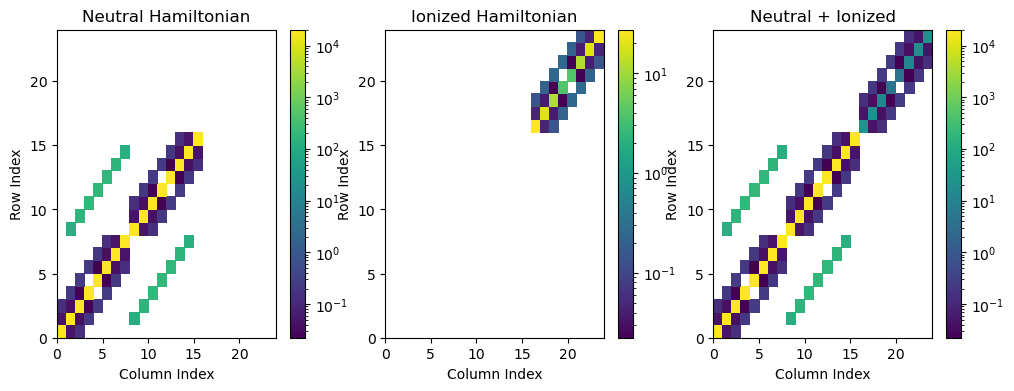

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
pcm1 = ax[0].pcolor(np.abs(H_neutral_full.full()), norm=LogNorm())
pcm2 = ax[1].pcolor(np.abs(H_ionized_full.full()), norm=LogNorm())
pcm3 = ax[2].pcolor(np.abs(H_full.full()), norm=LogNorm())
plt.colorbar(pcm1, ax=ax[0])
plt.colorbar(pcm2, ax=ax[1])
plt.colorbar(pcm3, ax=ax[2])
ax[0].set_title('Neutral Hamiltonian')
ax[1].set_title('Ionized Hamiltonian')
ax[2].set_title('Neutral + Ionized')

ax[0].set_xlabel('Column Index')
ax[0].set_ylabel('Row Index')
ax[1].set_xlabel('Column Index')
ax[1].set_ylabel('Row Index')
ax[2].set_xlabel('Column Index')
ax[2].set_ylabel('Row Index')

## compute eigenvalues and eigenvectors

In [6]:
(eigenvalues_full, eigenstates_full) = H_full.eigenstates()
eigenstate_full_matrix = np.zeros([24,24], dtype=complex)
for i in range(24):
    idx_argmax = np.argmax(np.abs(eigenstates_full[i].full().flatten())**2)
    eigenstate_full_matrix[idx_argmax] = eigenstates_full[i].full().flatten()

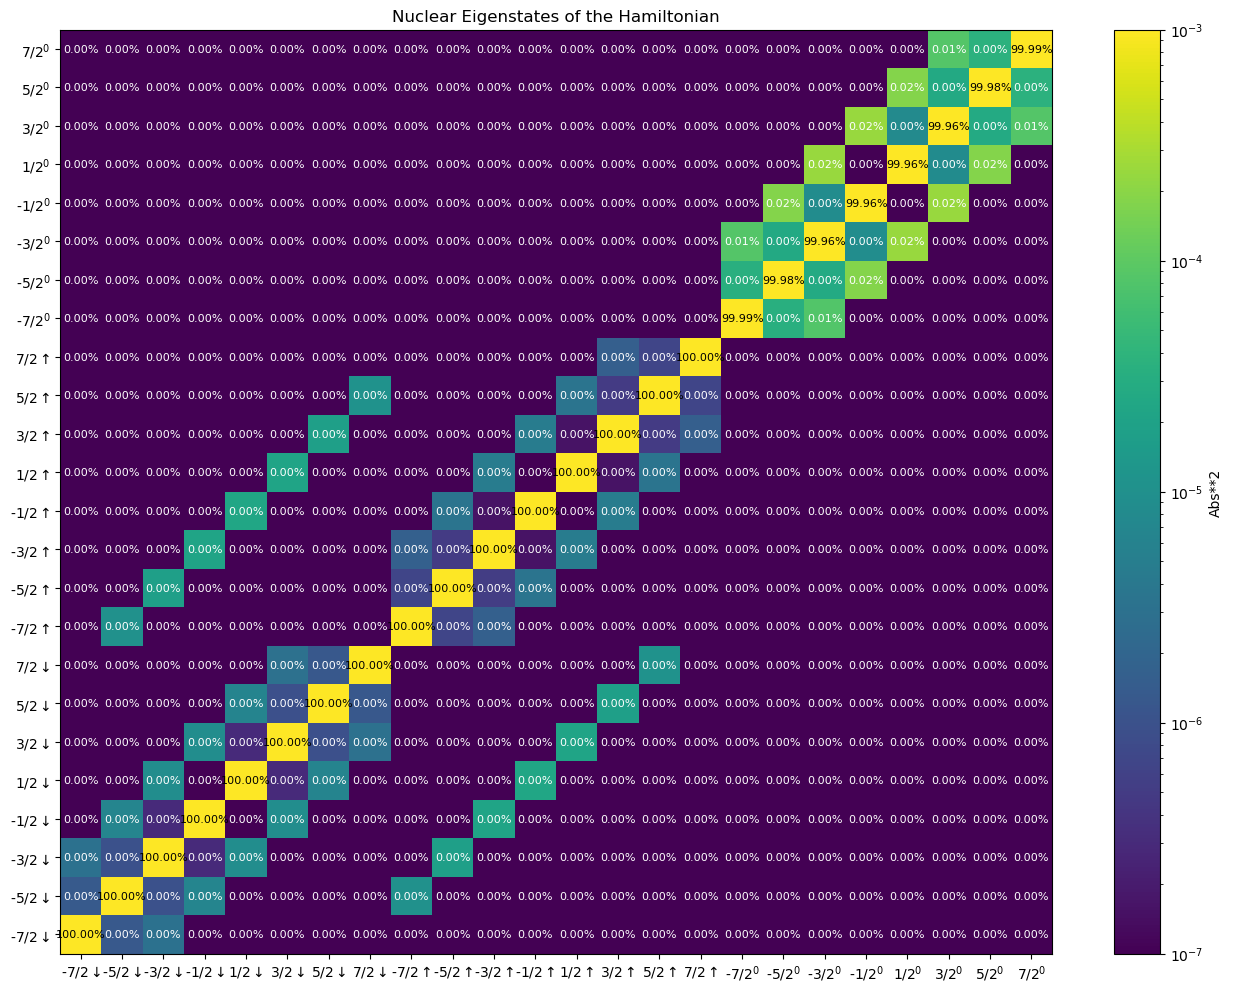

In [7]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
plot_eigenstate_decomposition(eigenstate_full_matrix, ax)

In [8]:
nmr_freqs = np.zeros(7)
for i in range(len(nmr_freqs)):
    nmr_freqs[i] = eigenvalues_full[8+i] - eigenvalues_full[8+i+1]

ESR_freqs = np.diff(np.abs(eigenvalues_full[:8] - eigenvalues_full[16:][::-1]))

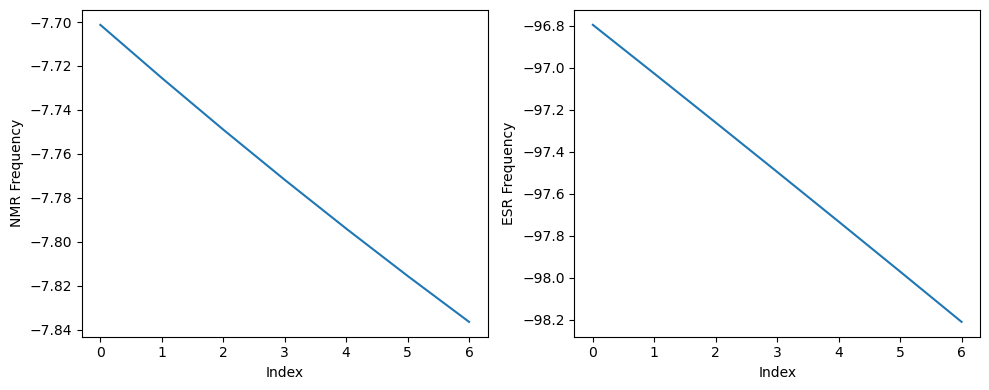

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(nmr_freqs)
ax[0].set_xlabel('Index')
ax[0].set_ylabel('NMR Frequency')
ax[1].plot(ESR_freqs)
ax[1].set_xlabel('Index')
ax[1].set_ylabel('ESR Frequency')
plt.tight_layout()

# Calculate ionization shock

In [10]:
# Compute transition probabilities via direct projection
transition_matrix_ionize_up = np.zeros((8, 8))
transition_matrix_ionize_down = np.zeros((8, 8))
transition_matrix_neutralize_down = np.zeros((8,8))
transition_matrix_neutralize_up = np.zeros((8,8))

for i in range(8):  # Neutral states
    for j in range(8):  # Ionized states

        transition_matrix_ionize_up[i, j] = np.abs(
            np.dot(eigenstate_full_matrix[8+i, 8:16].conj().T, eigenstate_full_matrix[16 + j, 16:])
        )**2 + np.dot(eigenstate_full_matrix[8+i, :8].conj().T, eigenstate_full_matrix[16 + j, 16:])**2

        transition_matrix_ionize_down[i, j] = np.abs(
            np.dot(eigenstate_full_matrix[i, :8].conj().T, eigenstate_full_matrix[16 + j, 16:])
        )**2 + np.dot(eigenstate_full_matrix[i, 8:16].conj().T, eigenstate_full_matrix[16 + j, 16:])**2

transition_matrix_neutralize_up = transition_matrix_ionize_up
transition_matrix_neutralize_down = transition_matrix_ionize_down

C:\Users\z5380600\AppData\Local\Temp\ipykernel_12212\1835168255.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  transition_matrix_ionize_up[i, j] = np.abs(
C:\Users\z5380600\AppData\Local\Temp\ipykernel_12212\1835168255.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  transition_matrix_ionize_down[i, j] = np.abs(


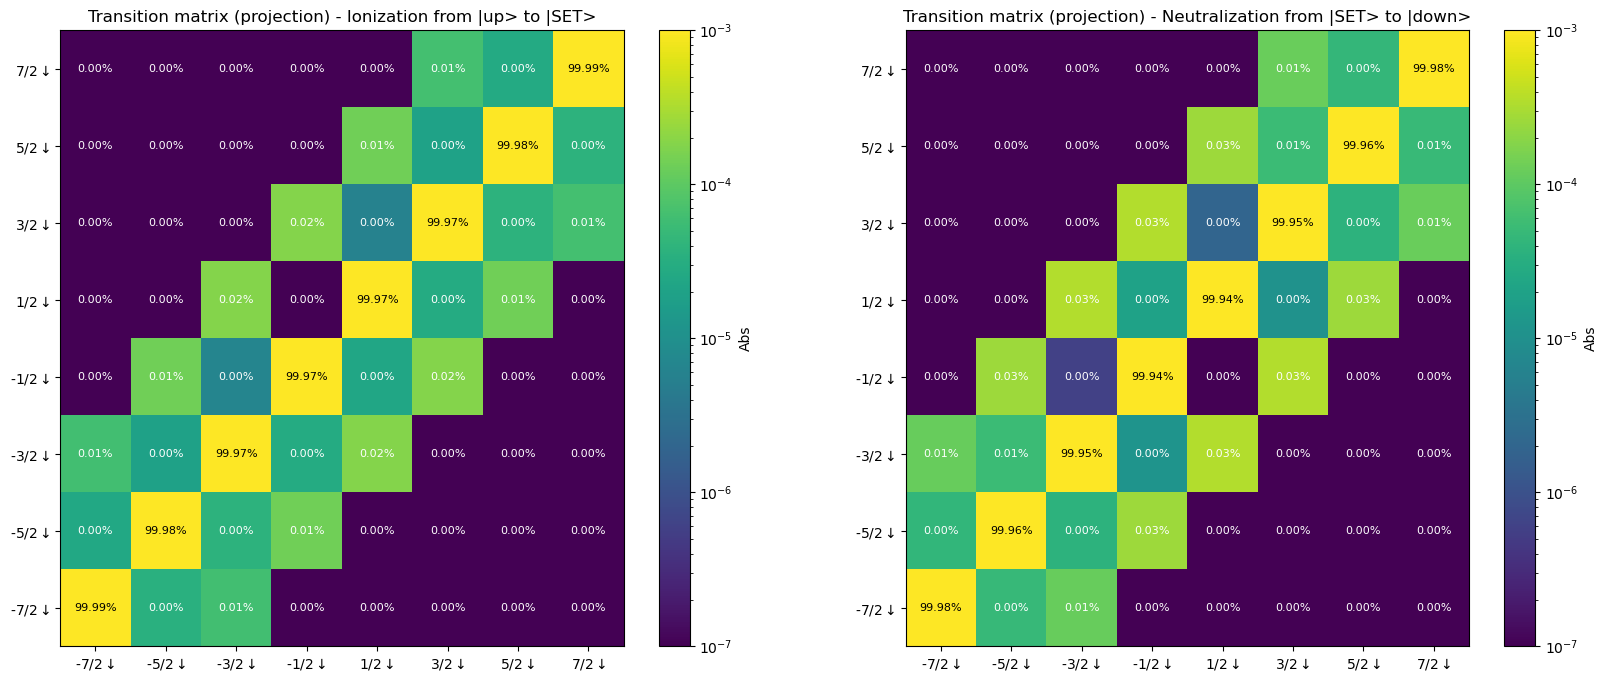

In [11]:
fig, ax = plt.subplots(1,2, figsize=(20,8))

title_ionize = 'Transition matrix (projection) - Ionization from |up> to |SET>'
plot_transition_matrix(transition_matrix_ionize_up, ax[0], title=title_ionize)
title_neutralize = 'Transition matrix (projection) - Neutralization from |SET> to |down>'
plot_transition_matrix(transition_matrix_neutralize_down, ax[1], title=title_neutralize)

In [16]:
np.save(r'sims_data/neutralization_down_matrix.npy', np.abs(transition_matrix_neutralize_down))
np.save(r'sims_data/ionization_up_matrix.npy', np.abs(transition_matrix_ionize_up))

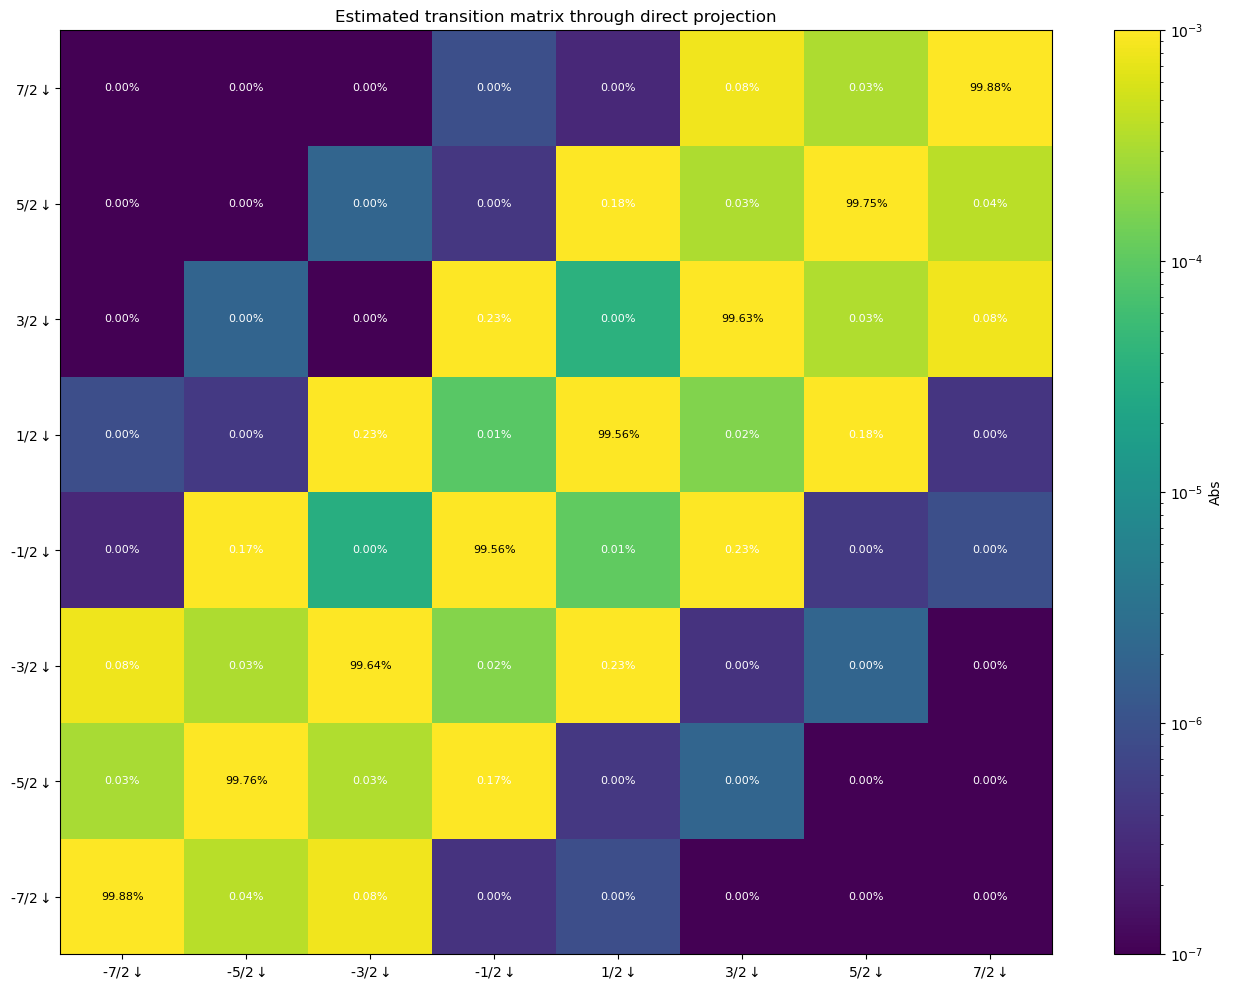

In [12]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
n_tunnel = 4.47
T_est = fractional_matrix_power(np.abs(transition_matrix_neutralize_down) @ np.abs(transition_matrix_ionize_up), n_tunnel)

plot_transition_matrix(T_est, ax, title='Estimated transition matrix through direct projection')

In [18]:
np.save(r'sims_data/ionization_matrix_proj.npy', T_est)